# Partial Derivatives using SymPy

A **partial derivative** measures how a function changes when we vary **one variable** while keeping all other variables fixed.

For a function $f(x, y)$:
- $\frac{\partial f}{\partial x}$ — differentiate with respect to $x$, treat $y$ as a constant
- $\frac{\partial f}{\partial y}$ — differentiate with respect to $y$, treat $x$ as a constant

In this notebook, we'll use `sympy.diff()` to compute partial derivatives symbolically.

In [1]:
import sympy
sympy.init_printing()

# Define symbols once — we'll reuse them throughout
x, y = sympy.symbols('x y')

## Example 1: $f(x,y) = x^2 + y^2$

Expected results:

$$\frac{\partial f}{\partial x} = 2x \qquad \frac{\partial f}{\partial y} = 2y$$

Since each variable's term is independent, the partial derivative with respect to one variable simply ignores the other.

In [2]:
f1 = x**2 + y**2
display(f1)

print("∂f/∂x ="); display(sympy.diff(f1, x))
print("∂f/∂y ="); display(sympy.diff(f1, y))

∂f/∂x =


∂f/∂y =


## Example 2: $f(x,y) = x^2 \cdot y^2$

Expected results:

$$\frac{\partial f}{\partial x} = 2x \cdot y^2 \qquad \frac{\partial f}{\partial y} = x^2 \cdot 2y$$

Here the variables are multiplied together, so when differentiating with respect to one, the other acts as a **constant coefficient** (product rule).

In [3]:
f2 = x**2 * y**2
display(f2)

print("∂f/∂x ="); display(sympy.diff(f2, x))
print("∂f/∂y ="); display(sympy.diff(f2, y))

∂f/∂x =


∂f/∂y =


## Evaluating Partial Derivatives at a Point

Symbolic derivatives are useful, but we often need **numeric values** — for example, to compute a gradient step. Use `.subs()` to plug in specific values.

Let's evaluate the partial derivatives of $f_1(x,y) = x^2 + y^2$ at the point $(3, 4)$:

$$\frac{\partial f_1}{\partial x}\bigg|_{(3,4)} = 2(3) = 6 \qquad \frac{\partial f_1}{\partial y}\bigg|_{(3,4)} = 2(4) = 8$$

In [4]:
f1_dx = sympy.diff(f1, x)
f1_dy = sympy.diff(f1, y)

point = {x: 3, y: 4}

print(f"f1 at {point}:")
print("∂f/∂x =", f1_dx.subs(point))
print("∂f/∂y =", f1_dy.subs(point))

f1 at {x: 3, y: 4}:
∂f/∂x = 6
∂f/∂y = 8


## The Gradient Vector

The **gradient** collects all partial derivatives into a single vector:

$$\nabla f(x,y) = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$$

The gradient points in the direction of **steepest increase** of the function — this is the foundation of **gradient descent**, where we move in the *opposite* direction to minimize a loss function.

∇f₁ =


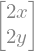

∇f₁ at {x: 3, y: 4} =


In [5]:
# Gradient of f1 = x^2 + y^2
gradient_f1 = sympy.Matrix([sympy.diff(f1, x), sympy.diff(f1, y)])
print("∇f₁ ="); display(gradient_f1)

# Evaluate gradient at (3, 4)
gradient_at_point = gradient_f1.subs(point)
print(f"∇f₁ at {point} ="); display(gradient_at_point)

## 3D Surface Plot

Let's visualize $f_1(x,y) = x^2 + y^2$ as a surface. This helps build intuition:
- Moving along a **slice** where $y$ is fixed shows the effect captured by $\frac{\partial f}{\partial x}$
- Moving along a **slice** where $x$ is fixed shows the effect captured by $\frac{\partial f}{\partial y}$

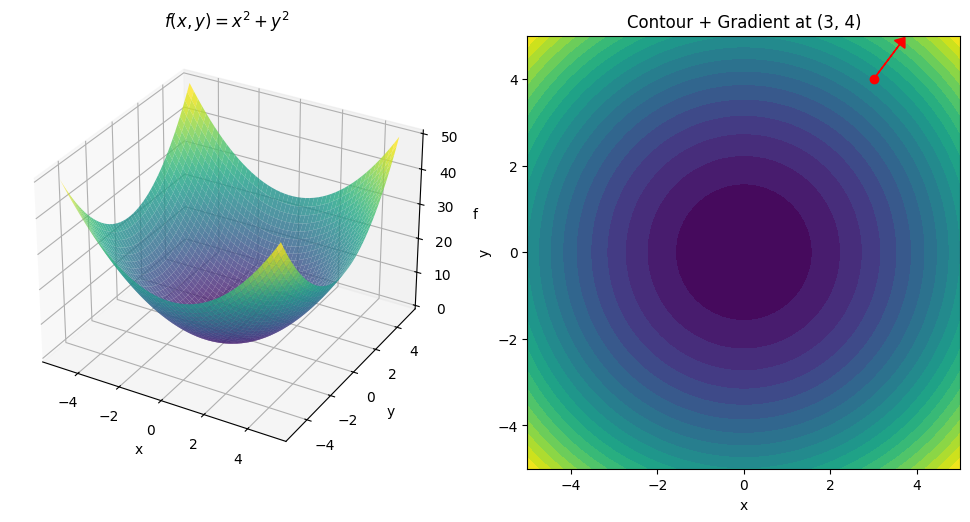

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))

# --- Surface plot ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
xs = np.linspace(-5, 5, 50)
ys = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(xs, ys)
Z = X**2 + Y**2
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_title('$f(x,y) = x^2 + y^2$')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('f')

# --- Contour plot with gradient arrow at (3, 4) ---
ax2 = fig.add_subplot(1, 2, 2)
ax2.contourf(X, Y, Z, levels=20, cmap='viridis')
ax2.set_title('Contour + Gradient at (3, 4)')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
# Gradient at (3,4) is [6, 8] — draw as an arrow
ax2.arrow(3, 4, 0.6, 0.8, head_width=0.3, head_length=0.2, fc='red', ec='red')
ax2.plot(3, 4, 'ro', markersize=6)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

## Higher-Order and Mixed Partial Derivatives

We can differentiate more than once:
- **Second-order**: $\frac{\partial^2 f}{\partial x^2}$ — differentiate w.r.t. $x$ twice
- **Mixed partial**: $\frac{\partial^2 f}{\partial x \, \partial y}$ — differentiate w.r.t. $x$, then $y$

By **Schwarz's theorem**, for smooth functions the mixed partials are equal:

$$\frac{\partial^2 f}{\partial x \, \partial y} = \frac{\partial^2 f}{\partial y \, \partial x}$$

The matrix of all second-order partials is called the **Hessian** — it captures curvature information.

f₂ =


∂²f/∂x² =


∂²f/∂y² =


∂²f/∂x∂y =


∂²f/∂y∂x =


Mixed partials equal? True

Hessian of f₂:


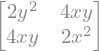

In [7]:
# Using f2 = x^2 * y^2
print("f₂ ="); display(f2)

# Second-order partials
f2_xx = sympy.diff(f2, x, 2)
f2_yy = sympy.diff(f2, y, 2)
print("∂²f/∂x² ="); display(f2_xx)
print("∂²f/∂y² ="); display(f2_yy)

# Mixed partials (should be equal)
f2_xy = sympy.diff(f2, x, y)
f2_yx = sympy.diff(f2, y, x)
print("∂²f/∂x∂y ="); display(f2_xy)
print("∂²f/∂y∂x ="); display(f2_yx)
print("Mixed partials equal?", sympy.simplify(f2_xy - f2_yx) == 0)

# Hessian matrix
H = sympy.Matrix([[f2_xx, f2_xy],
                   [f2_yx, f2_yy]])
print("\nHessian of f₂:"); display(H)

## Example 3: A More Complex Function

$$f(x,y) = x \cdot e^y + \sin(x \cdot y)$$

This exercises multiple differentiation rules at once:
- **Product rule**: $x \cdot e^y$ — treat $e^y$ as constant when differentiating w.r.t. $x$
- **Chain rule**: $\sin(x \cdot y)$ — the inner function $x \cdot y$ must also be differentiated

f₃ =


∂f/∂x =


∂f/∂y =



∇f₃ =


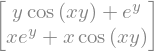


∇f₃ at {x: 1, y: 0} =


In [8]:
f3 = x * sympy.exp(y) + sympy.sin(x * y)
print("f₃ ="); display(f3)

print("∂f/∂x ="); display(sympy.diff(f3, x))
print("∂f/∂y ="); display(sympy.diff(f3, y))

# Gradient
gradient_f3 = sympy.Matrix([sympy.diff(f3, x), sympy.diff(f3, y)])
print("\n∇f₃ ="); display(gradient_f3)

# Evaluate at (1, 0)
point3 = {x: 1, y: 0}
print(f"\n∇f₃ at {point3} ="); display(gradient_f3.subs(point3))